# Real Exoplanet Data + Machine Learning Demo  
## NASA Exoplanet Archive → exploratory analysis → simple ML model

This Google Colab notebook downloads **real confirmed exoplanet data** from the NASA Exoplanet Archive using its TAP service, performs exploratory analysis, and builds a simple machine-learning model.

**Main learning goals**

1. Query real astronomical data programmatically.
2. Clean physical parameters with missing values.
3. Visualize exoplanet populations.
4. Build ML features from physical quantities.
5. Train and interpret a model using scikit-learn.

**Scientific caution:** the `pscomppars` table is a composite table. It is very useful for population-level ML demonstrations, but parameters can come from different literature sources and are not always self-consistent for detailed physical inference.


## 1. Imports

We use standard Python scientific libraries. In Google Colab, these are usually already installed.


In [1]:
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

pd.set_option("display.max_columns", 100)


## 2. Query NASA Exoplanet Archive

NASA Exoplanet Archive provides programmatic access through TAP.  
We query the **Planetary Systems Composite Parameters** table, `pscomppars`.

The selected columns include:

| Column | Meaning |
|---|---|
| `pl_name` | planet name |
| `hostname` | host-star name |
| `discoverymethod` | discovery technique |
| `disc_year` | discovery year |
| `pl_orbper` | orbital period, days |
| `pl_rade` | planet radius, Earth radii |
| `pl_bmasse` | planet mass, Earth masses |
| `pl_dens` | bulk density |
| `pl_eqt` | equilibrium temperature |
| `st_teff` | stellar effective temperature |
| `st_rad` | stellar radius |
| `st_mass` | stellar mass |
| `sy_dist` | system distance, pc |

We request rows where at least planet radius and orbital period are known.


In [2]:
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = """
SELECT
    pl_name, hostname, discoverymethod, disc_year,
    pl_orbper, pl_rade, pl_bmasse, pl_dens, pl_eqt,
    st_teff, st_rad, st_mass, sy_dist
FROM pscomppars
WHERE pl_rade IS NOT NULL
  AND pl_orbper IS NOT NULL
"""

params = {
    "query": query,
    "format": "csv"
}

url = base_url + "?" + urllib.parse.urlencode(params)
print(url[:300] + "...")

df = pd.read_csv(url)
print(df.shape)
df.head()


https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=%0ASELECT%0A++++pl_name%2C+hostname%2C+discoverymethod%2C+disc_year%2C%0A++++pl_orbper%2C+pl_rade%2C+pl_bmasse%2C+pl_dens%2C+pl_eqt%2C%0A++++st_teff%2C+st_rad%2C+st_mass%2C+sy_dist%0AFROM+pscomppars%0AWHERE+pl_rade+IS+NOT+NULL%0A++AND+pl_orbpe...
(5887, 13)


,pl_name,hostname,discoverymethod,disc_year,pl_orbper,pl_rade,pl_bmasse,pl_dens,pl_eqt,st_teff,st_rad,st_mass,sy_dist
0,Kepler-1167 b,Kepler-1167,Transit,2016.0,1.003934,1.710000,3.570,3.92,1419.0,4971.0,0.750,0.790,820.905
1,Kepler-1740 b,Kepler-1740,Transit,2021.0,8.172400,3.323214,11.000,1.65,858.0,5705.0,0.905,0.943,1061.770
2,Kepler-1581 b,Kepler-1581,Transit,2016.0,6.283855,0.800000,0.437,4.69,1108.0,6022.0,1.230,1.120,493.175
3,Kepler-644 b,Kepler-644,Transit,2016.0,3.173917,3.150000,10.100,1.78,1655.0,6747.0,1.810,1.490,1318.050
4,Kepler-1752 b,Kepler-1752,Transit,2021.0,56.358501,4.540605,18.700,1.10,419.0,5446.0,0.821,0.824,962.888


## 3. Basic data inspection

Real astronomical catalogues are not clean ML tables.  
They contain missing values, mixed measurement origins, detection biases, and selection effects.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5887 entries, 0 to 5886
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          5887 non-null   str    
 1   hostname         5887 non-null   str    
 2   discoverymethod  5887 non-null   str    
 3   disc_year        5886 non-null   float64
 4   pl_orbper        5887 non-null   float64
 5   pl_rade          5887 non-null   float64
 6   pl_bmasse        5863 non-null   float64
 7   pl_dens          5797 non-null   float64
 8   pl_eqt           4617 non-null   float64
 9   st_teff          5863 non-null   float64
 10  st_rad           5852 non-null   float64
 11  st_mass          5886 non-null   float64
 12  sy_dist          5867 non-null   float64
dtypes: float64(10), str(3)
memory usage: 763.5 KB


In [4]:
missing_fraction = df.isna().mean().sort_values(ascending=False)
missing_fraction


pl_eqt             0.215730
pl_dens            0.015288
st_rad             0.005945
pl_bmasse          0.004077
st_teff            0.004077
sy_dist            0.003397
disc_year          0.000170
st_mass            0.000170
pl_name            0.000000
pl_orbper          0.000000
discoverymethod    0.000000
hostname           0.000000
pl_rade            0.000000
dtype: float64

## 4. Physical feature engineering

Many planetary quantities span orders of magnitude.  
For ML and visualization, it is often better to use logarithms:

$$
\log_{10} P,\quad \log_{10} R_p,\quad \log_{10} M_p.
$$

This is especially useful because exoplanet populations are distributed over wide dynamic ranges.


In [5]:
data = df.copy()

# Keep only physically positive values before applying log10.
for col in ["pl_orbper", "pl_rade", "pl_bmasse", "pl_dens", "pl_eqt", "st_teff", "st_rad", "st_mass", "sy_dist"]:
    data.loc[data[col] <= 0, col] = np.nan

data["logP"] = np.log10(data["pl_orbper"])
data["logR"] = np.log10(data["pl_rade"])
data["logM"] = np.log10(data["pl_bmasse"])

data[["pl_name", "discoverymethod", "pl_orbper", "pl_rade", "pl_bmasse", "logP", "logR", "logM"]].head()


,pl_name,discoverymethod,pl_orbper,pl_rade,pl_bmasse,logP,logR,logM
0,Kepler-1167 b,Transit,1.003934,1.710000,3.570,0.001705,0.232996,0.552668
1,Kepler-1740 b,Transit,8.172400,3.323214,11.000,0.912350,0.521558,1.041393
2,Kepler-1581 b,Transit,6.283855,0.800000,0.437,0.798226,-0.096910,-0.359519
3,Kepler-644 b,Transit,3.173917,3.150000,10.100,0.501596,0.498311,1.004321
4,Kepler-1752 b,Transit,56.358501,4.540605,18.700,1.750959,0.657114,1.271842


## 5. Visualize the exoplanet population

### Radius vs orbital period

This plot already contains a lot of selection physics:

- Transit surveys easily find **large planets** and **short-period planets**.
- Long-period small planets are much harder to detect.
- The observed distribution is not the intrinsic planet population.


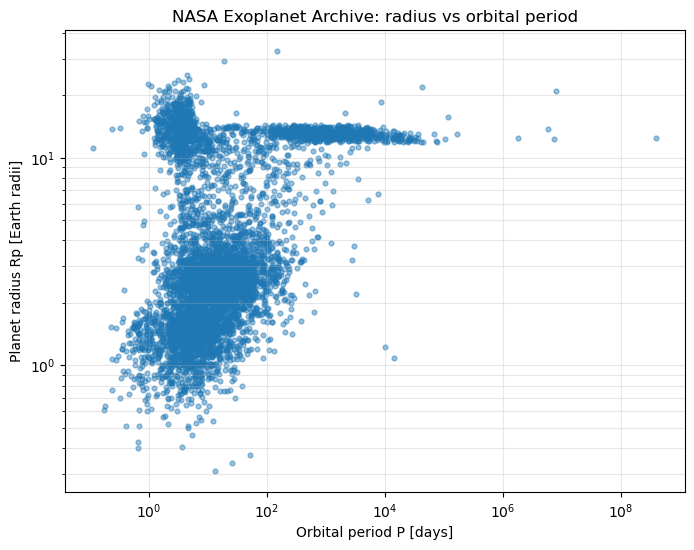

In [6]:
plot_df = data.dropna(subset=["pl_orbper", "pl_rade"])

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["pl_orbper"], plot_df["pl_rade"], s=12, alpha=0.45)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Orbital period P [days]")
plt.ylabel("Planet radius Rp [Earth radii]")
plt.title("NASA Exoplanet Archive: radius vs orbital period")
plt.grid(True, which="both", alpha=0.3)
plt.show()


### Mass-radius diagram

A mass-radius diagram is a compact way to compare physical classes of planets.  
For a rough intuition:

- rocky planets occupy the low-radius, low-mass regime;
- gas giants occupy large radii and high masses;
- sub-Neptunes and super-Earths lie between them.


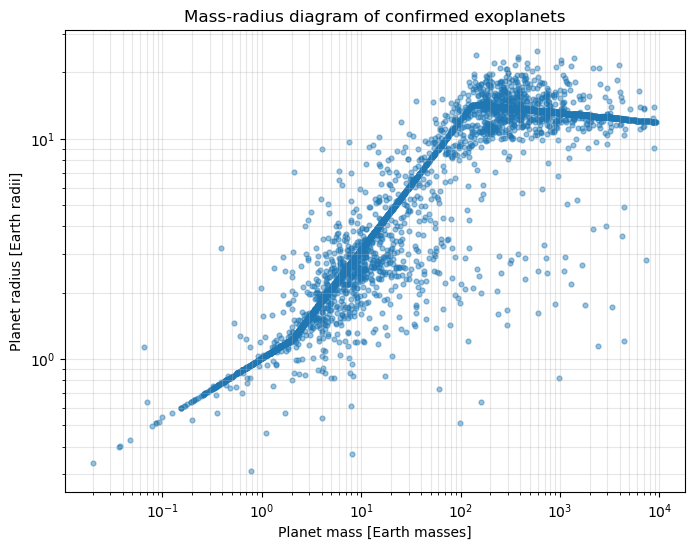

In [7]:
mr = data.dropna(subset=["pl_bmasse", "pl_rade"])

plt.figure(figsize=(8, 6))
plt.scatter(mr["pl_bmasse"], mr["pl_rade"], s=12, alpha=0.45)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Planet mass [Earth masses]")
plt.ylabel("Planet radius [Earth radii]")
plt.title("Mass-radius diagram of confirmed exoplanets")
plt.grid(True, which="both", alpha=0.3)
plt.show()


## 6. Define a simple physical class label

For teaching ML, we define planet-size classes from radius:

$$
R_p < 1.25 R_\oplus \quad \Rightarrow \quad \text{terrestrial}
$$

$$
1.25 \le R_p < 2 \quad \Rightarrow \quad \text{super-Earth}
$$

$$
2 \le R_p < 6 \quad \Rightarrow \quad \text{sub-Neptune / Neptune-like}
$$

$$
R_p \ge 6 \quad \Rightarrow \quad \text{giant}
$$

This is a pedagogical classification, not a strict astrophysical taxonomy.


In [8]:
def radius_class(r):
    if pd.isna(r):
        return np.nan
    if r < 1.25:
        return "terrestrial"
    elif r < 2.0:
        return "super-Earth"
    elif r < 6.0:
        return "sub-Neptune"
    else:
        return "giant"

data["radius_class"] = data["pl_rade"].apply(radius_class)
data["radius_class"].value_counts(dropna=False)


radius_class
sub-Neptune    2322
giant          1813
super-Earth    1180
terrestrial     572
Name: count, dtype: int64

## 7. ML task A: predict planet radius from other parameters

We now build a regression model:

$$
\widehat{\log_{10} R_p}
=
f_\theta(\log_{10}P,\log_{10}M_p,T_{\rm eq},T_{\rm eff},R_\star,M_\star,d,\text{discovery method})
$$

Target:

$$
y=\log_{10}R_p
$$

Features:

- orbital period;
- mass;
- density/equilibrium temperature if available;
- stellar parameters;
- discovery method.

We deliberately use a model that can handle nonlinear relations: **Random Forest Regression**.


In [9]:
features_num = ["logP", "logM", "pl_dens", "pl_eqt", "st_teff", "st_rad", "st_mass", "sy_dist", "disc_year"]
features_cat = ["discoverymethod"]
target = "logR"

reg_df = data.dropna(subset=[target]).copy()

X = reg_df[features_num + features_cat]
y = reg_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, features_num),
    ("cat", categorical_pipe, features_cat)
])

reg_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3,
        n_jobs=-1
    ))
])

reg_model.fit(X_train, y_train)
pred = reg_model.predict(X_test)

mae_log = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE in log10 radius:", mae_log)
print("Approx multiplicative radius error:", 10**mae_log)
print("R^2:", r2)


MAE in log10 radius: 0.01833788482977363
Approx multiplicative radius error: 1.0431286768261185
R^2: 0.9731922228931523


## 8. Regression diagnostic plot

If the model is perfect, points lie on the diagonal line.

Because the catalogue is heterogeneous and has missing values, this should be treated as an ML demonstration, not a precision physical model.


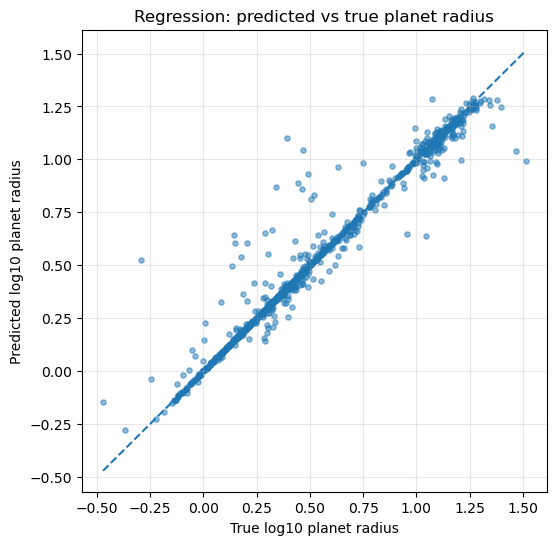

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=14, alpha=0.5)

lo = min(y_test.min(), pred.min())
hi = max(y_test.max(), pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

plt.xlabel("True log10 planet radius")
plt.ylabel("Predicted log10 planet radius")
plt.title("Regression: predicted vs true planet radius")
plt.grid(True, alpha=0.3)
plt.show()


## 9. ML task B: classify planet-size class

Now we ask a classification question:

$$
x \rightarrow \text{planet-size class}
$$

We will **not use `pl_rade` or `logR` as input**, because that would leak the answer.  
Instead, the model uses orbital, mass, density, stellar, and discovery-method information.


In [11]:
clf_df = data.dropna(subset=["radius_class"]).copy()

X = clf_df[features_num + features_cat]
y = clf_df["radius_class"]

# Remove very rare classes if any class has too few samples for stable splitting.
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 20].index
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3,
        class_weight="balanced",
        n_jobs=-1
    ))
])

clf_model.fit(X_train, y_train)
ypred = clf_model.predict(X_test)

print(classification_report(y_test, ypred))


              precision    recall  f1-score   support

       giant       0.95      0.98      0.97       453
 sub-Neptune       0.96      0.96      0.96       581
 super-Earth       0.94      0.96      0.95       295
 terrestrial       0.98      0.85      0.91       143

    accuracy                           0.96      1472
   macro avg       0.96      0.94      0.95      1472
weighted avg       0.96      0.96      0.95      1472



## 10. Confusion matrix

Rows are true classes.  
Columns are predicted classes.

The diagonal contains correct predictions.


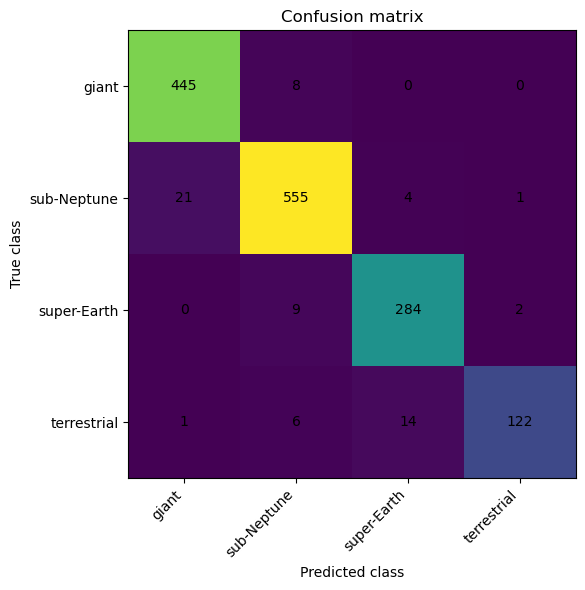

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, ypred, labels=labels)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 11. Feature importance

Random forests provide a rough measure of feature importance.  
This is not causal interpretation, but it helps students ask which measurements are informative.


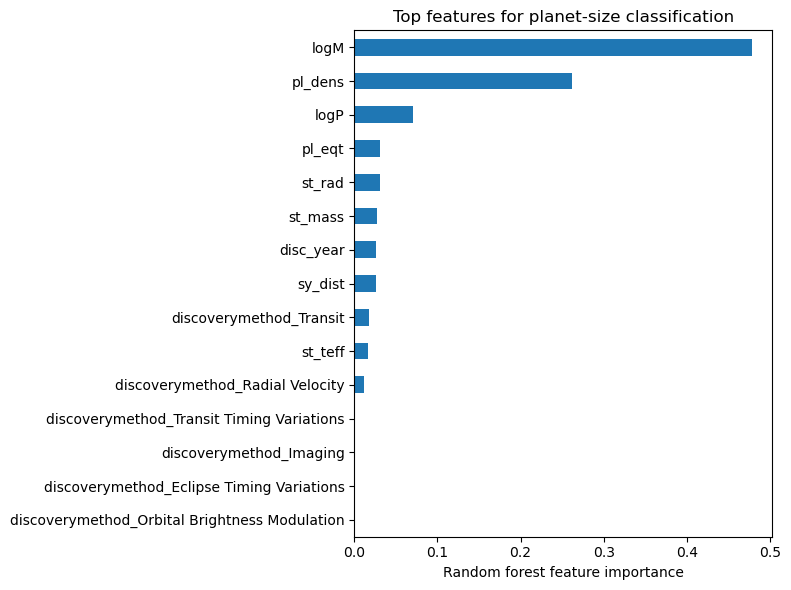

logM                                             0.478774
pl_dens                                          0.262281
logP                                             0.071123
pl_eqt                                           0.031087
st_rad                                           0.030369
st_mass                                          0.027154
disc_year                                        0.026620
sy_dist                                          0.026344
discoverymethod_Transit                          0.017642
st_teff                                          0.016332
discoverymethod_Radial Velocity                  0.011732
discoverymethod_Transit Timing Variations        0.000358
discoverymethod_Imaging                          0.000088
discoverymethod_Eclipse Timing Variations        0.000050
discoverymethod_Orbital Brightness Modulation    0.000033
dtype: float64

In [13]:
# Get feature names after preprocessing.
pre = clf_model.named_steps["preprocess"]
model = clf_model.named_steps["model"]

num_names = features_num
cat_names = list(pre.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(features_cat))
all_names = num_names + cat_names

importances = pd.Series(model.feature_importances_, index=all_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Random forest feature importance")
plt.title("Top features for planet-size classification")
plt.tight_layout()
plt.show()

importances.head(15)


## 12. Optional: compare detection methods

The distribution of discovered planets depends strongly on the discovery method.  
This is a selection-effect lesson: the observed catalogue is shaped by instruments and detection strategies.


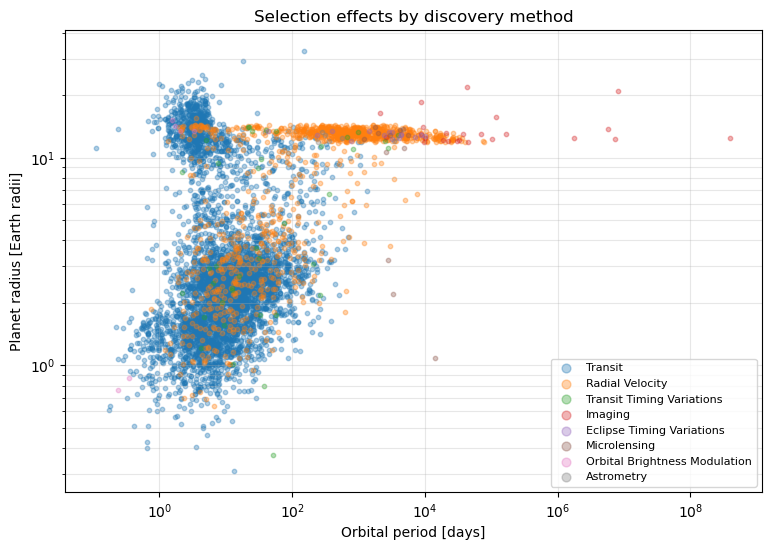

In [14]:
top_methods = data["discoverymethod"].value_counts().head(8).index
method_df = data[data["discoverymethod"].isin(top_methods)]

plt.figure(figsize=(9, 6))
for method in top_methods:
    sub = method_df[method_df["discoverymethod"] == method].dropna(subset=["pl_orbper", "pl_rade"])
    plt.scatter(sub["pl_orbper"], sub["pl_rade"], s=10, alpha=0.35, label=method)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Orbital period [days]")
plt.ylabel("Planet radius [Earth radii]")
plt.title("Selection effects by discovery method")
plt.legend(markerscale=2, fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.show()


## 13. Discussion questions for students

1. Why is it dangerous to interpret ML feature importance as physical causality?
2. Why are short-period planets overrepresented in transit surveys?
3. Which missing values are random, and which are caused by observing limitations?
4. Why do logarithms help for exoplanet population data?
5. How would results change if we trained only on transiting planets?
6. What would be a better physically motivated target than radius class?
7. How would you include measurement uncertainties?
8. How would you design a validation strategy that tests generalization to future discoveries?


## 14. Extension tasks

### Easy
- Add histograms of planet radius, mass, and orbital period.
- Compare discovery year distributions by discovery method.

### Medium
- Train the classifier only on `Transit` planets.
- Train a model to predict discovery method.
- Use cross-validation instead of one train/test split.

### Advanced
- Add measurement uncertainties as features.
- Use Bayesian regression or Gaussian processes.
- Model selection effects explicitly.
- Compare supervised learning with clustering in mass-radius-period space.
